# Lab Problem 7: Gaussian Discriminant Analysis

This notebook implements Gaussian Discriminant Analysis (GDA) on the Iris dataset using **Sepal Length** and **Sepal Width** as features, then visualizes the decision boundaries and Gaussian contour lines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, :2]
y = iris.target
class_names = iris.target_names

n, d = X.shape
K = len(np.unique(y))

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Classes: {list(class_names)}")

Feature matrix shape: (150, 2)
Label vector shape: (150,)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [2]:
mus = np.zeros((K, d))
Sigmas = np.zeros((K, d, d))
phis = np.zeros(K)

for k in range(K):
    Xk = X[y == k]
    mus[k] = Xk.mean(axis=0)
    centered = Xk - mus[k]
    Sigmas[k] = centered.T @ centered / Xk.shape[0]
    Sigmas[k] += 1e-6 * np.eye(d)
    phis[k] = Xk.shape[0] / n

print("Class mean vectors:")
for k, class_name in enumerate(class_names):
    print(f"{class_name:>10}: {mus[k]}")

Class mean vectors:
    setosa: [5.006 3.428]
versicolor: [5.936 2.77 ]
 virginica: [6.588 2.974]


In [3]:
def log_multivariate_gaussian(x, mean, cov):
    x = np.atleast_2d(x)
    diff = x - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        raise ValueError("Covariance matrix must be positive definite.")
    solved = np.linalg.solve(cov, diff.T).T
    mahal = np.sum(diff * solved, axis=1)
    return -0.5 * (diff.shape[1] * np.log(2 * np.pi) + logdet + mahal)


def GDA_predictions(x, mus, Sigmas, phis):
    x = np.atleast_2d(x)
    scores = np.column_stack([
        log_multivariate_gaussian(x, mus[k], Sigmas[k]) + np.log(phis[k])
        for k in range(len(phis))
    ])
    predictions = np.argmax(scores, axis=1)
    return predictions if len(predictions) > 1 else predictions[0]


y_pred = GDA_predictions(X, mus, Sigmas, phis)
accuracy = np.mean(y_pred == y)
print(f"Training accuracy: {accuracy:.3f}")

Training accuracy: 0.800


In [4]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = GDA_predictions(grid, mus, Sigmas, phis).reshape(xx.shape)
gaussian_contours = [
    np.exp(log_multivariate_gaussian(grid, mus[k], Sigmas[k])).reshape(xx.shape)
    for k in range(K)
]

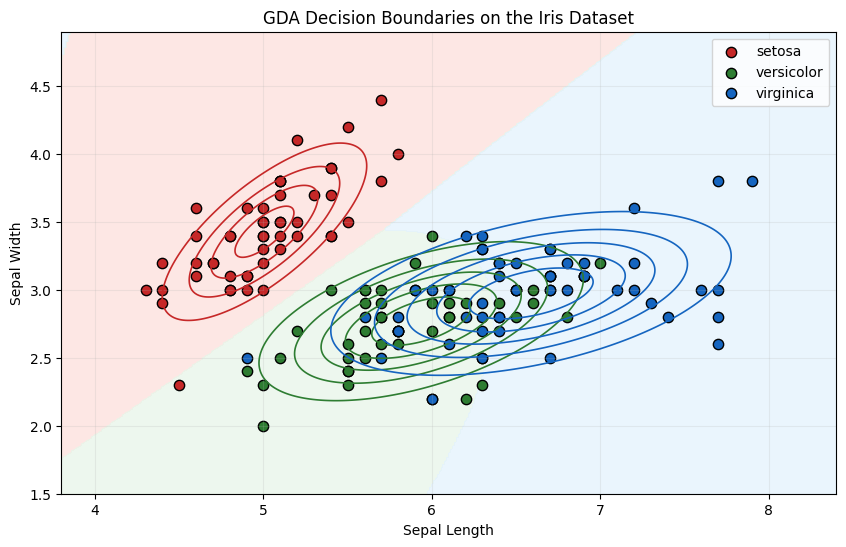

In [5]:
region_cmap = ListedColormap(["#fde0dc", "#e8f5e9", "#e3f2fd"])
point_colors = ["#c62828", "#2e7d32", "#1565c0"]

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, levels=np.arange(K + 1) - 0.5, cmap=region_cmap, alpha=0.75)

for k, class_name in enumerate(class_names):
    plt.contour(xx, yy, gaussian_contours[k], levels=5, colors=[point_colors[k]], linewidths=1.2)
    plt.scatter(
        X[y == k, 0],
        X[y == k, 1],
        c=point_colors[k],
        edgecolor="black",
        s=55,
        label=class_name
    )

plt.title("GDA Decision Boundaries on the Iris Dataset")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.grid(alpha=0.2)
plt.show()